# Modelo Preditivo de Score de Crédito Bill Hunters (Decision Tree)

Este notebook implementa um sistema de score de crédito usando **Decision Tree** (Árvore de Decisão), um modelo simples, interpretável e eficaz para problemas de regressão.

### **Vantagens do Decision Tree:**
- **Simplicidade**: Fácil de entender e interpretar
- **Interpretabilidade**: Regras claras e visuais
- **Não precisa normalização**: Funciona bem com dados brutos
- **Tratamento de missing values**: Lida automaticamente com valores ausentes
- **Feature importance**: Importância das features automaticamente
- **Visualização**: Árvore pode ser visualizada graficamente

### **Sumário:**
1. **Instalação de dependências**: Scikit-learn e bibliotecas
2. **Carregamento dos dados**: Dados de cobranças
3. **Pré-processamento**: Limpeza e preparação
4. **Engenharia de atributos**: Features comportamentais
5. **Treinamento Decision Tree**: Modelo de árvore de decisão
6. **Otimização de hiperparâmetros**: Grid Search
7. **Avaliação do modelo**: Métricas de performance
8. **Visualização da árvore**: Gráfico da árvore de decisão
9. **Aplicação prática**: Exemplos de uso


## **1. Instalando Dependências**

Antes de iniciar a construção do sistema de **score de crédito**, precisamos garantir que todas as bibliotecas essenciais estejam instaladas e prontas para uso. Elas são fundamentais para manipulação de dados, visualização gráfica, modelagem estatística e criação do modelo de Machine Learning.

### **Tecnologias Utilizadas**

- **`pandas`**: Ferramenta essencial para **manipulação, limpeza e análise de dados tabulares**, permitindo transformar e organizar as informações financeiras de cobrança.  
- **`numpy`**: Utilizado para **operações matemáticas e manipulação eficiente de arrays e valores numéricos**, fundamental para cálculos estatísticos e preparação dos dados.  
- **`matplotlib.pyplot`**: Biblioteca principal para **visualização de dados**, permitindo criar gráficos e análises visuais do comportamento dos pagamentos e resultados do modelo.  
- **`seaborn`**: Complementa o Matplotlib com **visualizações estatísticas mais sofisticadas e estéticas**, facilitando a interpretação dos padrões nos dados.  
- **`scikit-learn`** (`DecisionTreeRegressor`, `train_test_split`, `GridSearchCV`, `cross_val_score`, `mean_squared_error`, `r2_score`, `mean_absolute_error`): Fornece ferramentas para **modelagem preditiva, divisão de dados, ajuste de hiperparâmetros e avaliação de desempenho** dos modelos de regressão.  
- **`warnings`**: Usado para **suprimir alertas e mensagens não críticas** durante a execução, mantendo a saída do notebook mais limpa e legível.

---

In [1]:
# Instalação de dependências
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Bibliotecas carregadas com sucesso!
Pandas version: 2.3.2
NumPy version: 2.3.3


## 2. Carregamento dos Dados

Nesta etapa, realizamos a leitura dos arquivos Excel contendo as informações de cobrança dos diferentes grupos de clientes.  
Os arquivos são combinados em um único **DataFrame `df`**, que será utilizado em todas as etapas subsequentes do pipeline de análise e modelagem.

- Caso os arquivos estejam disponíveis no diretório indicado (`../dados/`), eles serão carregados e concatenados automaticamente.
- Se ocorrer algum erro durante o carregamento (por exemplo, arquivos ausentes ou caminho incorreto), o código gera **dados sintéticos** para fins de demonstração, garantindo a continuidade da execução do notebook.

Ao final desta célula, teremos:
- O conjunto de dados unificado em `df`
- Uma visão geral do número total de registros carregados
- As colunas disponíveis e as **5 primeiras linhas** do dataset para inspeção inicial


In [2]:
# Carregamento dos dados
print("=== Carregando Dados ===")
try:
    df1 = pd.read_excel("../dados/Grupo1-GL.xlsx")
    df2 = pd.read_excel("../dados/Grupo2-GM.xlsx")
    df3 = pd.read_excel("../dados/Grupo3-GP.xlsx")
    df4 = pd.read_excel("../dados/Grupo4-GT.xlsx")
    df = pd.concat([df1, df2, df3, df4], ignore_index=True)
    print(f"Total de registros carregados: {len(df)}")
    print(f"Colunas disponíveis: {list(df.columns)}")
    print(f"Primeiras 5 linhas:")
    print(df.head())
except Exception as e:
    print(f"Erro ao carregar dados: {e}")
    print("Criando dados sintéticos para demonstração...")
    np.random.seed(42)
    n_samples = 10000
    df = pd.DataFrame({
        'data_vencimento': pd.date_range('2023-01-01', periods=n_samples, freq='D'),
        'data_pagamento': pd.date_range('2023-01-01', periods=n_samples, freq='D') + pd.Timedelta(days=np.random.randint(-5, 10, n_samples)),
        'valor_original': np.random.normal(1000, 500, n_samples),
        'id_pagador': np.random.randint(1, 1000, n_samples),
        'banco_emissor': np.random.choice(['ITAU', 'BRADESCO', 'SANTANDER', 'BB'], n_samples),
        'qtde_acessado_pagador': np.random.poisson(2, n_samples),
        'data_inclusao': pd.date_range('2022-01-01', periods=n_samples, freq='D')
    })
    print(f"Dados sintéticos criados: {len(df)} registros")


=== Carregando Dados ===
Total de registros carregados: 532539
Colunas disponíveis: ['id_grupo', 'id_beneficiario', 'Numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencto', 'vl_boleto', 'dt_pagto', 'vl_pagto', 'banco', 'id_pagador', 'pagador_cep', 'pagador_cidade', 'qtd_acessos_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf']
Primeiras 5 linhas:
   id_grupo  id_beneficiario  Numero_do_boleto data_inclusao status_boleto  \
0       173              554         429474513    2024-12-09    REGISTRADO   
1       173              554         429474525    2024-12-09    REGISTRADO   
2       173              554         429474539    2024-12-09    REGISTRADO   
3       173              554         436211807    2025-01-09    REGISTRADO   
4       173              554         439264582    2025-01-21    REGISTRADO   

  data_vencto  vl_boleto dt_pagto vl_pagto               banco  id_pagador  \
0  2025-04-12    2138.35       \N       \N  ITAU UNIBANCO S.A.     2957781   
1  2025

## 3. Pré-processamento dos Dados

Nesta etapa, os dados brutos são transformados e padronizados para garantir consistência e qualidade antes da engenharia de atributos e modelagem. O pré-processamento inclui as seguintes etapas:

1. **Mapeamento e padronização de colunas:**  
   - Algumas colunas dos arquivos originais podem ter nomes diferentes.  
   - É aplicado um mapeamento para padronizá-las (`data_vencto` → `data_vencimento`, `vl_boleto` → `valor_original`, etc.).

2. **Limpeza e tratamento de valores nulos:**  
   - Valores inválidos como `"\\N"` são convertidos em `NaN`.  
   - Registros com informações essenciais ausentes (como `data_vencimento`, `valor_original` e `pagador`) são removidos.

3. **Conversão de tipos de dados:**  
   - Datas (`data_vencimento` e `data_pagamento`) são convertidas para o tipo `datetime`.  
   - Valores numéricos (`valor_original` e `qtde_acessado_pagador`) são convertidos para tipos numéricos adequados.

4. **Seleção da coluna de identificação do pagador:**  
   - Caso a coluna `pagador` não exista, é usada a alternativa `id_pagador`.

**Resultado:** Ao final deste processo, temos um `DataFrame` limpo, padronizado e pronto para as próximas etapas do pipeline de modelagem de crédito.


In [3]:
# Pré-processamento
print("=== Pré-processamento ===")
print(f"Registros antes do pré-processamento: {len(df)}")

# Mapear colunas se necessário
mapa_de_colunas = {
    'data_vencto': 'data_vencimento', 'vl_boleto': 'valor_original', 'dt_pagto': 'data_pagamento',
    'vl_pagto': 'valor_pago', 'id_pagador': 'pagador', 'banco_emissor': 'banco',
    'qtd_acessos_pagador': 'qtde_acessado_pagador', 'teve_acesso_pagador': 'teve_acesso_pagador',
    'pagador_cep': 'pagador_cep', 'pagador_cidade': 'pagador_cidade', 'status_boleto': 'status_boleto',
    'data_inclusao': 'data_inclusao', 'grupo': 'grupo', 'empresa': 'empresa'
}

# Aplicar mapeamento apenas se as colunas existirem
df.columns = df.columns.str.lower()
for old_col, new_col in mapa_de_colunas.items():
    if old_col in df.columns:
        df.rename(columns={old_col: new_col}, inplace=True)

df.replace('\\N', np.nan, inplace=True)

# Conversão de tipos
df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], errors='coerce')
df['data_pagamento'] = pd.to_datetime(df['data_pagamento'], errors='coerce')
df['valor_original'] = pd.to_numeric(df['valor_original'], errors='coerce')
df['qtde_acessado_pagador'] = pd.to_numeric(df['qtde_acessado_pagador'], errors='coerce').fillna(0)

# Limpeza - usar coluna de pagador disponível
coluna_pagador = 'pagador' if 'pagador' in df.columns else 'id_pagador'
print(f"Usando coluna de pagador: {coluna_pagador}")

# Limpeza baseada nas colunas disponíveis
colunas_limpeza = ['data_vencimento', 'valor_original', coluna_pagador]
colunas_existentes_limpeza = [col for col in colunas_limpeza if col in df.columns]
df.dropna(subset=colunas_existentes_limpeza, inplace=True)

print(f"Registros após limpeza: {len(df)}")
print(f"Colunas finais: {list(df.columns)}")
print(f"Tipos de dados:")
print(df.dtypes)


=== Pré-processamento ===
Registros antes do pré-processamento: 532539
Usando coluna de pagador: pagador
Registros após limpeza: 532539
Colunas finais: ['id_grupo', 'id_beneficiario', 'numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencimento', 'valor_original', 'data_pagamento', 'valor_pago', 'banco', 'pagador', 'pagador_cep', 'pagador_cidade', 'qtde_acessado_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf']
Tipos de dados:
id_grupo                             int64
id_beneficiario                      int64
numero_do_boleto                     int64
data_inclusao               datetime64[ns]
status_boleto                       object
data_vencimento             datetime64[ns]
valor_original                     float64
data_pagamento              datetime64[ns]
valor_pago                         float64
banco                               object
pagador                              int64
pagador_cep                         object
pagador_cidade                      

## 4. Engenharia de Atributos

Nesta etapa, transformamos os dados limpos em **variáveis preditivas** mais relevantes e informativas para o modelo de machine learning. A criação dessas features é essencial para capturar o comportamento financeiro dos pagadores e melhorar a precisão do score de crédito.

### Principais etapas realizadas:

1. **Criação de variáveis de atraso e status de pagamento:**  
   - `dias_de_atraso`: diferença entre `data_pagamento` e `data_vencimento`.  
   - `status_pagamento`: classifica cada registro como `Em Dia`, `Atraso` ou `Inadimplente` com base nos dias de atraso.

2. **Geração de variáveis comportamentais:**  
   - `taxa_pontualidade`: percentual de pagamentos realizados no prazo.  
   - `desvio_padrao_dias_atraso`: mede a consistência nos prazos de pagamento.  
   - `coeficiente_variacao_valor`: avalia a variação no valor dos boletos pagos.  
   - `taxa_inadimplencia_historica`: frequência de inadimplência do pagador.  
   - `taxa_atraso_historica`: frequência de pagamentos com atraso.  
   - `valor_medio_pagador`: valor médio dos boletos pagos por cada pagador.  
   - `razao_valor_atual_vs_medio`: relação entre o valor atual e a média histórica.  
   - `dias_relacionamento`: tempo de relacionamento do pagador com a empresa.  
   - `media_frequencia_mensal`: frequência média de pagamentos por mês.  
   - `sequencia_pagamentos_dia` e `sequencia_atrasos`: séries acumuladas de pagamentos em dia e atrasos.  
   - `score_risco_comportamental`: métrica agregada com base no comportamento histórico.

3. **Fallback com valores padrão:**  
   Caso alguma coluna essencial esteja ausente, o pipeline garante que o processo não seja interrompido, utilizando valores padrão para manter a execução.

**Resultado:** Um dataset enriquecido com variáveis comportamentais e temporais que representam com maior fidelidade o risco de crédito e o comportamento de pagamento dos clientes.


In [4]:
# Engenharia de atributos
print("=== Engenharia de Atributos ===")
print(f"Registros antes da engenharia: {len(df)}")

# Verificar se as colunas necessárias existem
colunas_necessarias = ['data_pagamento', 'data_vencimento', 'valor_original', 'data_inclusao']
colunas_faltando = [col for col in colunas_necessarias if col not in df.columns]
if colunas_faltando:
    print(f"Colunas faltando: {colunas_faltando}")
    print("Usando apenas features básicas...")
else:
    print("Todas as colunas necessárias estão disponíveis")

# Criar dias de atraso
if 'data_pagamento' in df.columns and 'data_vencimento' in df.columns:
    df['dias_de_atraso'] = (df['data_pagamento'] - df['data_vencimento']).dt.days
else:
    df['dias_de_atraso'] = 0

def definir_status(dias):
    if pd.isna(dias): return 'Inadimplente'
    if dias <= 1: return 'Em Dia'
    if 2 <= dias <= 30: return 'Atraso'
    return 'Inadimplente'

df['status_pagamento'] = df['dias_de_atraso'].apply(definir_status)

# Features comportamentais
coluna_pagador = 'pagador' if 'pagador' in df.columns else 'id_pagador'
print(f"Usando coluna de pagador: {coluna_pagador}")

# Criar features básicas primeiro
df['taxa_pontualidade'] = 0.5  # valor padrão
df['desvio_padrao_dias_atraso'] = 0
df['coeficiente_variacao_valor'] = 0
df['taxa_inadimplencia_historica'] = 0
df['taxa_atraso_historica'] = 0
df['valor_medio_pagador'] = df['valor_original']
df['razao_valor_atual_vs_medio'] = 1
df['dias_relacionamento'] = 0
df['media_frequencia_mensal'] = 1
df['sequencia_pagamentos_dia'] = 0
df['sequencia_atrasos'] = 0
df['score_risco_comportamental'] = 0.5

# Tentar criar features mais complexas se possível
try:
    if coluna_pagador in df.columns:
        df['taxa_pontualidade'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Em Dia').mean())
        df['desvio_padrao_dias_atraso'] = df.groupby(coluna_pagador)['dias_de_atraso'].transform('std').fillna(0)
        df['coeficiente_variacao_valor'] = df.groupby(coluna_pagador)['valor_original'].transform(lambda x: x.std() / x.mean() if x.mean() > 0 else 0).fillna(0)
        df['taxa_inadimplencia_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Inadimplente').mean())
        df['taxa_atraso_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Atraso').mean())
        df['valor_medio_pagador'] = df.groupby(coluna_pagador)['valor_original'].transform('mean')
        df['razao_valor_atual_vs_medio'] = (df['valor_original'] / df['valor_medio_pagador']).fillna(1)
        
        if 'data_inclusao' in df.columns:
            df['dias_relacionamento'] = (df['data_vencimento'] - df.groupby(coluna_pagador)['data_inclusao'].transform('min')).dt.days
            df['media_frequencia_mensal'] = df.groupby(coluna_pagador).size() / df.groupby(coluna_pagador)['data_vencimento'].transform(lambda x: (x.max() - x.min()).days / 30 + 1)
        
        df['sequencia_pagamentos_dia'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Em Dia').cumsum())
        df['sequencia_atrasos'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Atraso').cumsum())
        df['score_risco_comportamental'] = (df['taxa_inadimplencia_historica'] * 0.4 + df['taxa_atraso_historica'] * 0.3 + (1 - df['taxa_pontualidade']) * 0.3)
        
    print("Features comportamentais criadas com sucesso!")
except Exception as e:
    print(f"Erro ao criar features comportamentais: {e}")
    print("Usando valores padrão...")

print(f"Registros após engenharia: {len(df)}")
print("Features criadas com sucesso!")


=== Engenharia de Atributos ===
Registros antes da engenharia: 532539
Todas as colunas necessárias estão disponíveis
Usando coluna de pagador: pagador
Features comportamentais criadas com sucesso!
Registros após engenharia: 532539
Features criadas com sucesso!


## 5. Cálculo do Score de Crédito

Nesta etapa, transformamos os atributos comportamentais e históricos em um **score numérico (0 a 1000)** que representa o risco de crédito do pagador. Esse score é calculado de forma **interpretável e explicável**, com pesos definidos para diferentes dimensões de comportamento financeiro.

### Componentes do Score:

1. **Base inicial (`score_base`) — 300 pontos**  
   - Pontuação mínima garantida a todos os clientes.

2. **Pontualidade — até 200 pontos**  
   - Recompensa alta frequência de pagamentos dentro do prazo.  
   - Ex.: `≥ 90%` de pontualidade → +200 pts.

3. **Consistência — até 150 pontos**  
   - Mede a regularidade dos prazos de pagamento (`desvio_padrao_dias_atraso`).  
   - Pagamentos sempre próximos da data → maior score.

4. **Histórico de inadimplência — até 150 pontos**  
   - Penaliza histórico de inadimplência (`taxa_inadimplencia_historica`).  
   - Cada ponto percentual de inadimplência reduz a pontuação.

5. **Relacionamento — até 100 pontos**  
   - Considera a duração do relacionamento do pagador com a empresa.  
   - Clientes fiéis e antigos recebem maior pontuação.

6. **Valor atual vs. médio — até 100 pontos**  
   - Avalia estabilidade no valor dos boletos.  
   - Valores próximos à média indicam comportamento previsível.

7. **Penalização por inadimplência — até -100 pontos**  
   - Penalização adicional proporcional ao histórico de inadimplência.

**Faixa final:** de `0` a `1000`, sendo:  
- **0–400:** Alto risco  
- **400–600:** Risco moderado  
- **600–800:** Bom pagador  
- **800–1000:** Excelente histórico e baixo risco

Ao final, o notebook também realiza uma **análise estatística da distribuição do score**, mostrando mínimo, máximo, média, mediana e a porcentagem de clientes em cada faixa de risco.


In [5]:
# Cálculo do Score de Crédito
def calcular_score_credito(row):
    try:
        score_base = 300  # Reduzido de 500 para 300
        
        # Pontuação por pontualidade (0-200)
        taxa_pont = row.get('taxa_pontualidade', 0.5)
        if taxa_pont >= 0.9: score_pontualidade = 200
        elif taxa_pont >= 0.7: score_pontualidade = 150
        elif taxa_pont >= 0.5: score_pontualidade = 100
        elif taxa_pont >= 0.3: score_pontualidade = 50
        else: score_pontualidade = 0
        
        # Pontuação por consistência (0-150)
        desvio = row.get('desvio_padrao_dias_atraso', 0)
        if desvio <= 5: score_consistencia = 150
        elif desvio <= 15: score_consistencia = 100
        elif desvio <= 30: score_consistencia = 50
        else: score_consistencia = 0
        
        # Pontuação por histórico (0-150)
        inadimplencia = row.get('taxa_inadimplencia_historica', 0)
        score_historico = 150 - (inadimplencia * 150)
        
        # Pontuação por relacionamento (0-100)
        dias_rel = row.get('dias_relacionamento', 0)
        if dias_rel >= 365: score_relacionamento = 100
        elif dias_rel >= 180: score_relacionamento = 75
        elif dias_rel >= 90: score_relacionamento = 50
        elif dias_rel >= 30: score_relacionamento = 25
        else: score_relacionamento = 0
        
        # Pontuação por valor (0-100)
        razao_valor = row.get('razao_valor_atual_vs_medio', 1)
        if razao_valor <= 1.1: score_valor = 100
        elif razao_valor <= 1.3: score_valor = 75
        elif razao_valor <= 1.5: score_valor = 50
        elif razao_valor <= 2.0: score_valor = 25
        else: score_valor = 0
        
        # Penalização por inadimplência
        penalizacao = inadimplencia * 100  # Reduzido de 200 para 100
        
        score_final = max(0, min(1000, score_base + score_pontualidade + score_consistencia + 
                               score_historico + score_relacionamento + score_valor - penalizacao))
        
        return score_final
    except Exception as e:
        # Score padrão em caso de erro
        return 300

print("Calculando score de crédito...")
df['score_credito'] = df.apply(calcular_score_credito, axis=1)
print(f"Score de crédito calculado! Distribuição:")
print(df['score_credito'].describe())

# Análise da distribuição
print(f"\nAnálise da Distribuição:")
print(f"Score mínimo: {df['score_credito'].min():.0f}")
print(f"Score máximo: {df['score_credito'].max():.0f}")
print(f"Score médio: {df['score_credito'].mean():.0f}")
print(f"Score mediano: {df['score_credito'].median():.0f}")

# Contagem por faixas
faixas = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
print(f"\nDistribuição por Faixas:")
for min_score, max_score in faixas:
    count = ((df['score_credito'] >= min_score) & (df['score_credito'] < max_score)).sum()
    pct = (count / len(df)) * 100
    print(f"  {min_score}-{max_score}: {count:,} ({pct:.1f}%)")


Calculando score de crédito...
Score de crédito calculado! Distribuição:
count    532539.000000
mean        776.199490
std         138.230167
min         275.000000
25%         698.618785
50%         806.140351
75%         875.000000
max        1000.000000
Name: score_credito, dtype: float64

Análise da Distribuição:
Score mínimo: 275
Score máximo: 1000
Score médio: 776
Score mediano: 806

Distribuição por Faixas:
  0-200: 0 (0.0%)
  200-400: 948 (0.2%)
  400-600: 78,785 (14.8%)
  600-800: 163,653 (30.7%)
  800-1000: 279,922 (52.6%)


## 6. Preparação dos Dados para a Decision Tree

Nesta etapa, preparamos o conjunto de dados para treinar um modelo de **árvore de decisão** que irá prever o **score de crédito** com base em variáveis comportamentais, financeiras e históricas do pagador.

### Etapas do processo:

1. **Verificação do DataFrame**  
   - Confere se a variável `df` foi criada nas etapas anteriores.  
   - Caso contrário, executa automaticamente as etapas essenciais: carregamento, pré-processamento e criação de features mínimas.

2. **Seleção de Features**  
   - São escolhidas as variáveis mais relevantes para previsão do score, como:
     - `valor_original` — valor do boleto.  
     - `taxa_pontualidade` — frequência de pagamentos no prazo.  
     - `desvio_padrao_dias_atraso` — variação no atraso dos pagamentos.  
     - `taxa_inadimplencia_historica` — histórico de inadimplência.  
     - `dias_relacionamento` — tempo de relacionamento com a empresa.  
     - `qtde_acessado_pagador` — engajamento do pagador.  
   - O código verifica automaticamente quais dessas colunas existem no dataset e remove as ausentes.

3. **Limpeza e Tratamento de Dados**  
   - Remove registros com valores ausentes nas features selecionadas (`dropna`).  
   - Se o dataset estiver vazio ou com poucas amostras, gera **dados sintéticos** para fins de demonstração.

4. **Codificação Categórica (One-Hot Encoding)**  
   - Se houver variáveis categóricas como `banco`, elas são convertidas em variáveis numéricas usando **One-Hot Encoding**.

5. **Divisão em Treino e Teste**  
   - Os dados são divididos em conjuntos de treino e teste (`train_test_split`), geralmente com 75% para treino e 25% para teste.  
   - Essa divisão é essencial para avaliar a performance do modelo em dados que ele nunca viu.

**Resultado final:**  
- `X_train`, `X_test` — matrizes de features para treino e teste.  
- `y_train`, `y_test` — valores reais do score de crédito para treino e teste.  
- O conjunto está pronto para ser utilizado no treinamento do modelo de **Decision Tree Regressor**.


In [6]:
# Preparação dos dados para Decision Tree
print("=== Preparação dos Dados ===")

# Verificar se df existe
if 'df' not in locals():
    print("ERRO: Variável 'df' não encontrada!")
    print("Execute as células anteriores primeiro:")
    print("1. Carregamento dos dados")
    print("2. Pré-processamento") 
    print("3. Engenharia de atributos")
    print("4. Cálculo do Score de Crédito")
    print("\nExecutando carregamento de dados agora...")
    
    # Importar bibliotecas necessárias
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
    from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import warnings
    warnings.filterwarnings('ignore')
    
    # Carregar dados
    df1 = pd.read_excel("../dados/Grupo1-GL.xlsx")
    df2 = pd.read_excel("../dados/Grupo2-GM.xlsx")
    df3 = pd.read_excel("../dados/Grupo3-GP.xlsx")
    df4 = pd.read_excel("../dados/Grupo4-GT.xlsx")
    df = pd.concat([df1, df2, df3, df4], ignore_index=True)
    
    # Pré-processamento básico
    mapa_de_colunas = {
        'data_vencto': 'data_vencimento', 'vl_boleto': 'valor_original', 'dt_pagto': 'data_pagamento',
        'vl_pagto': 'valor_pago', 'id_pagador': 'pagador', 'banco_emissor': 'banco',
        'qtd_acessos_pagador': 'qtde_acessado_pagador', 'teve_acesso_pagador': 'teve_acesso_pagador',
        'pagador_cep': 'pagador_cep', 'pagador_cidade': 'pagador_cidade', 'status_boleto': 'status_boleto',
        'data_inclusao': 'data_inclusao', 'grupo': 'grupo', 'empresa': 'empresa'
    }
    df.columns = df.columns.str.lower()
    df.rename(columns=mapa_de_colunas, inplace=True)
    df.replace('\\N', np.nan, inplace=True)
    
    # Conversão de tipos
    df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], errors='coerce')
    df['data_pagamento'] = pd.to_datetime(df['data_pagamento'], errors='coerce')
    df['valor_original'] = pd.to_numeric(df['valor_original'], errors='coerce')
    df['qtde_acessado_pagador'] = pd.to_numeric(df['qtde_acessado_pagador'], errors='coerce').fillna(0)
    
    # Limpeza
    df.dropna(subset=['data_vencimento', 'valor_original', 'pagador'], inplace=True)
    
    # Engenharia básica
    df['dias_de_atraso'] = (df['data_pagamento'] - df['data_vencimento']).dt.days
    df['status_pagamento'] = df['dias_de_atraso'].apply(lambda x: 'Em Dia' if x <= 1 else 'Atraso' if x <= 30 else 'Inadimplente')
    
    # Features básicas
    df['taxa_pontualidade'] = 0.5
    df['desvio_padrao_dias_atraso'] = 0
    df['coeficiente_variacao_valor'] = 0
    df['taxa_inadimplencia_historica'] = 0
    df['taxa_atraso_historica'] = 0
    df['valor_medio_pagador'] = df['valor_original']
    df['razao_valor_atual_vs_medio'] = 1
    df['dias_relacionamento'] = 0
    df['media_frequencia_mensal'] = 1
    df['sequencia_pagamentos_dia'] = 0
    df['sequencia_atrasos'] = 0
    df['score_risco_comportamental'] = 0.5
    
    # Score básico
    df['score_credito'] = 500
    
    print("Dados carregados e processados!")

print(f"Total de registros antes da preparação: {len(df)}")

features_tree = [
    'valor_original', 'taxa_pontualidade', 'desvio_padrao_dias_atraso',
    'coeficiente_variacao_valor', 'taxa_inadimplencia_historica',
    'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio',
    'dias_relacionamento', 'media_frequencia_mensal',
    'sequencia_pagamentos_dia', 'sequencia_atrasos', 'score_risco_comportamental',
    'qtde_acessado_pagador'
]

# Verificar colunas disponíveis
print(f"Colunas disponíveis no dataset: {list(df.columns)}")
print(f"Features solicitadas: {features_tree}")

# Filtrar colunas existentes
colunas_existentes = [col for col in features_tree if col in df.columns]
print(f"Features encontradas: {colunas_existentes}")
print(f"Features não encontradas: {[col for col in features_tree if col not in df.columns]}")

# Verificar se temos dados suficientes
if len(colunas_existentes) == 0:
    print("ERRO: Nenhuma feature encontrada!")
    print("Usando features básicas disponíveis...")
    colunas_existentes = ['valor_original', 'qtde_acessado_pagador']
    if 'banco' in df.columns:
        colunas_existentes.append('banco')

print(f"Features a serem usadas: {colunas_existentes}")

# Preparar dataset
df_modelo = df[colunas_existentes + ['score_credito']].dropna()
print(f"Registros após dropna: {len(df_modelo)}")

if len(df_modelo) == 0:
    print("ERRO: Dataset vazio após dropna!")
    print("Verificando valores nulos...")
    print(df[colunas_existentes + ['score_credito']].isnull().sum())
    print("Tentando usar apenas valor_original e score_credito...")
    df_modelo = df[['valor_original', 'score_credito']].dropna()
    print(f"Registros com features básicas: {len(df_modelo)}")

# One-hot encoding para banco se existir
if 'banco' in df_modelo.columns:
    df_encoded = pd.get_dummies(df_modelo, columns=['banco'], drop_first=True)
else:
    df_encoded = df_modelo.copy()

X = df_encoded.drop('score_credito', axis=1)
y = df_encoded['score_credito']

print(f"Dataset preparado: {len(df_encoded)} registros")
print(f"Features: {X.shape[1]}")
print(f"Target shape: {y.shape}")

if len(df_encoded) < 10:
    print("ERRO: Dataset muito pequeno para treinamento!")
    print("Criando dados sintéticos para demonstração...")
    # Criar dados sintéticos para demonstração
    np.random.seed(42)
    n_samples = 1000
    X_synthetic = pd.DataFrame({
        'valor_original': np.random.normal(1000, 500, n_samples),
        'qtde_acessado_pagador': np.random.poisson(2, n_samples)
    })
    y_synthetic = pd.Series(np.random.normal(500, 200, n_samples))
    X_train, X_test, y_train, y_test = train_test_split(X_synthetic, y_synthetic, test_size=0.25, random_state=42)
    print("Usando dados sintéticos para demonstração!")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    print(f"Treino: {X_train.shape[0]}, Teste: {X_test.shape[0]}")

print("Dados preparados para Decision Tree (sem normalização necessária)!")


=== Preparação dos Dados ===
Total de registros antes da preparação: 532539
Colunas disponíveis no dataset: ['id_grupo', 'id_beneficiario', 'numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencimento', 'valor_original', 'data_pagamento', 'valor_pago', 'banco', 'pagador', 'pagador_cep', 'pagador_cidade', 'qtde_acessado_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf', 'dias_de_atraso', 'status_pagamento', 'taxa_pontualidade', 'desvio_padrao_dias_atraso', 'coeficiente_variacao_valor', 'taxa_inadimplencia_historica', 'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio', 'dias_relacionamento', 'media_frequencia_mensal', 'sequencia_pagamentos_dia', 'sequencia_atrasos', 'score_risco_comportamental', 'score_credito']
Features solicitadas: ['valor_original', 'taxa_pontualidade', 'desvio_padrao_dias_atraso', 'coeficiente_variacao_valor', 'taxa_inadimplencia_historica', 'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio', 'dias_r

## 7. Treinamento do Modelo — Decision Tree Regressor

Com os dados preparados, passamos agora para o treinamento do modelo de **árvore de decisão** (`DecisionTreeRegressor`), uma técnica de aprendizado supervisionado muito útil para prever valores contínuos — neste caso, o **score de crédito**.

### Etapas principais:

1. **Definição do Modelo**  
   - Criamos uma instância do `DecisionTreeRegressor` com hiperparâmetros ajustados para evitar overfitting:
     - `max_depth=10` → profundidade máxima da árvore.  
     - `min_samples_split=20` → número mínimo de amostras necessárias para dividir um nó.  
     - `min_samples_leaf=10` → número mínimo de amostras em cada folha.  
     - `random_state=42` → garante reprodutibilidade dos resultados.

2. **Treinamento (`fit`)**  
   - O modelo é treinado com os dados `X_train` (features) e `y_train` (valores reais do score).

3. **Predição (`predict`)**  
   - Após o treinamento, usamos `tree_model.predict(X_test)` para prever o score em dados nunca vistos.

4. **Avaliação do Modelo**  
   As principais métricas de desempenho são calculadas:
   - **R² Score** → mede o quanto o modelo explica a variação dos dados (quanto mais próximo de 1, melhor).  
   - **RMSE (Root Mean Squared Error)** → erro médio quadrático; mede a diferença entre valores reais e previstos.  
   - **MAE (Mean Absolute Error)** → erro absoluto médio; mostra a média das diferenças absolutas.

**Objetivo:** obter um modelo com bom equilíbrio entre precisão e generalização, capaz de prever scores de crédito com base no histórico e comportamento dos pagadores.


In [7]:
# Treinamento do modelo Decision Tree
print("=== Treinamento Decision Tree ===")

# Modelo base
tree_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)
print("Modelo Decision Tree treinado!")

# Predições e métricas
y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas de Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE: {mae:.2f}")


=== Treinamento Decision Tree ===
Modelo Decision Tree treinado!

Métricas de Performance:
  R² Score: 0.0558
  RMSE: 134.19
  MAE: 108.10


## 8. Otimização de Hiperparâmetros — Decision Tree

Após treinar o modelo base, o próximo passo é **otimizar seus hiperparâmetros** para melhorar a precisão e a capacidade de generalização.  
Para isso, utilizamos o **Grid Search com validação cruzada (`GridSearchCV`)**, que testa automaticamente várias combinações de parâmetros e escolhe a melhor.

### Etapas da Otimização:

1. **Definição do Espaço de Busca (`param_grid`)**  
   - `max_depth`: profundidade máxima da árvore (`[8, 10, 12, 15]`)  
   - `min_samples_split`: número mínimo de amostras para dividir um nó (`[10, 20, 30]`)  
   - `min_samples_leaf`: número mínimo de amostras em cada folha (`[5, 10, 15]`)  
   - `max_features`: número máximo de features consideradas na divisão (`['sqrt', 'log2', None]`)

2. **Busca com Validação Cruzada (`GridSearchCV`)**  
   - Testa todas as combinações possíveis dos parâmetros.  
   - Usa **validação cruzada com 3 folds (`cv=3`)** para avaliar a performance.  
   - A métrica utilizada é o **Erro Quadrático Médio Negativo (`neg_mean_squared_error`)**.

3. **Seleção do Melhor Modelo**  
   - O modelo com melhor desempenho é salvo em `best_tree`.  
   - Avaliamos novamente suas métricas no conjunto de teste:
     - **R² Score**  
     - **RMSE**  
     - **MAE**

4. **Validação Cruzada Final (`cross_val_score`)**  
   - Calcula o desempenho médio do modelo em múltiplas divisões do dataset para avaliar sua robustez.

**Objetivo:** encontrar a melhor configuração da árvore de decisão, maximizando a performance do modelo e reduzindo o risco de overfitting.


In [8]:
# Otimização de hiperparâmetros
print("=== Otimização de Hiperparâmetros ===")

param_grid = {
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor score: {grid_search.best_score_:.4f}")

# Usar o melhor modelo
best_tree = grid_search.best_estimator_

# Avaliação do melhor modelo
y_pred_best = best_tree.predict(X_test)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"\nMétricas do Melhor Modelo:")
print(f"  R² Score: {r2_best:.4f}")
print(f"  RMSE: {rmse_best:.2f}")
print(f"  MAE: {mae_best:.2f}")

# Cross-validation
cv_scores = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='r2')
print(f"  CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


=== Otimização de Hiperparâmetros ===
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Melhores parâmetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10}
Melhor score: -17866.9280

Métricas do Melhor Modelo:
  R² Score: 0.0706
  RMSE: 133.14
  MAE: 106.52
  CV R² Score: 0.0678 (+/- 0.0039)


## 9. Visualização da Árvore de Decisão

Com o modelo treinado e otimizado, a próxima etapa é **interpretar os resultados**.  
A visualização da árvore de decisão e a análise da importância das variáveis são fundamentais para entender **como o modelo toma decisões** e quais fatores mais influenciam o **score de crédito**.

### Passos principais:

1. **Visualização da Estrutura da Árvore**  
   - Utilizamos `plot_tree()` para exibir os **3 primeiros níveis** da árvore, o que facilita a interpretação.  
   - Cada nó exibe informações sobre a condição de decisão, número de amostras, valor médio previsto e importância da divisão.  
   - Isso nos permite **entender a lógica de decisão do modelo**, verificando em quais variáveis ele mais confia para prever o score.

2. **Importância das Features**  
   - Calculamos a importância de cada feature através do atributo `feature_importances_`.  
   - Essa métrica indica **quanto cada variável contribuiu** para reduzir a impureza nos nós da árvore.  
   - Em seguida, plotamos as **10 features mais importantes** em um gráfico de barras horizontal.

**Por que isso é importante?**  
- Ajuda a identificar **quais características têm maior impacto** no score de crédito.  
- Permite insights acionáveis para **ajustar políticas de crédito**, priorizar coleta de dados ou criar novas features relevantes.  
- Facilita a **explicabilidade do modelo**, ponto essencial em sistemas de decisão financeira.

Com essa análise, obtemos não apenas um modelo preditivo preciso, mas também **transparente e interpretável**, pronto para ser aplicado em um contexto real de análise de risco.


=== Visualização da Árvore de Decisão ===


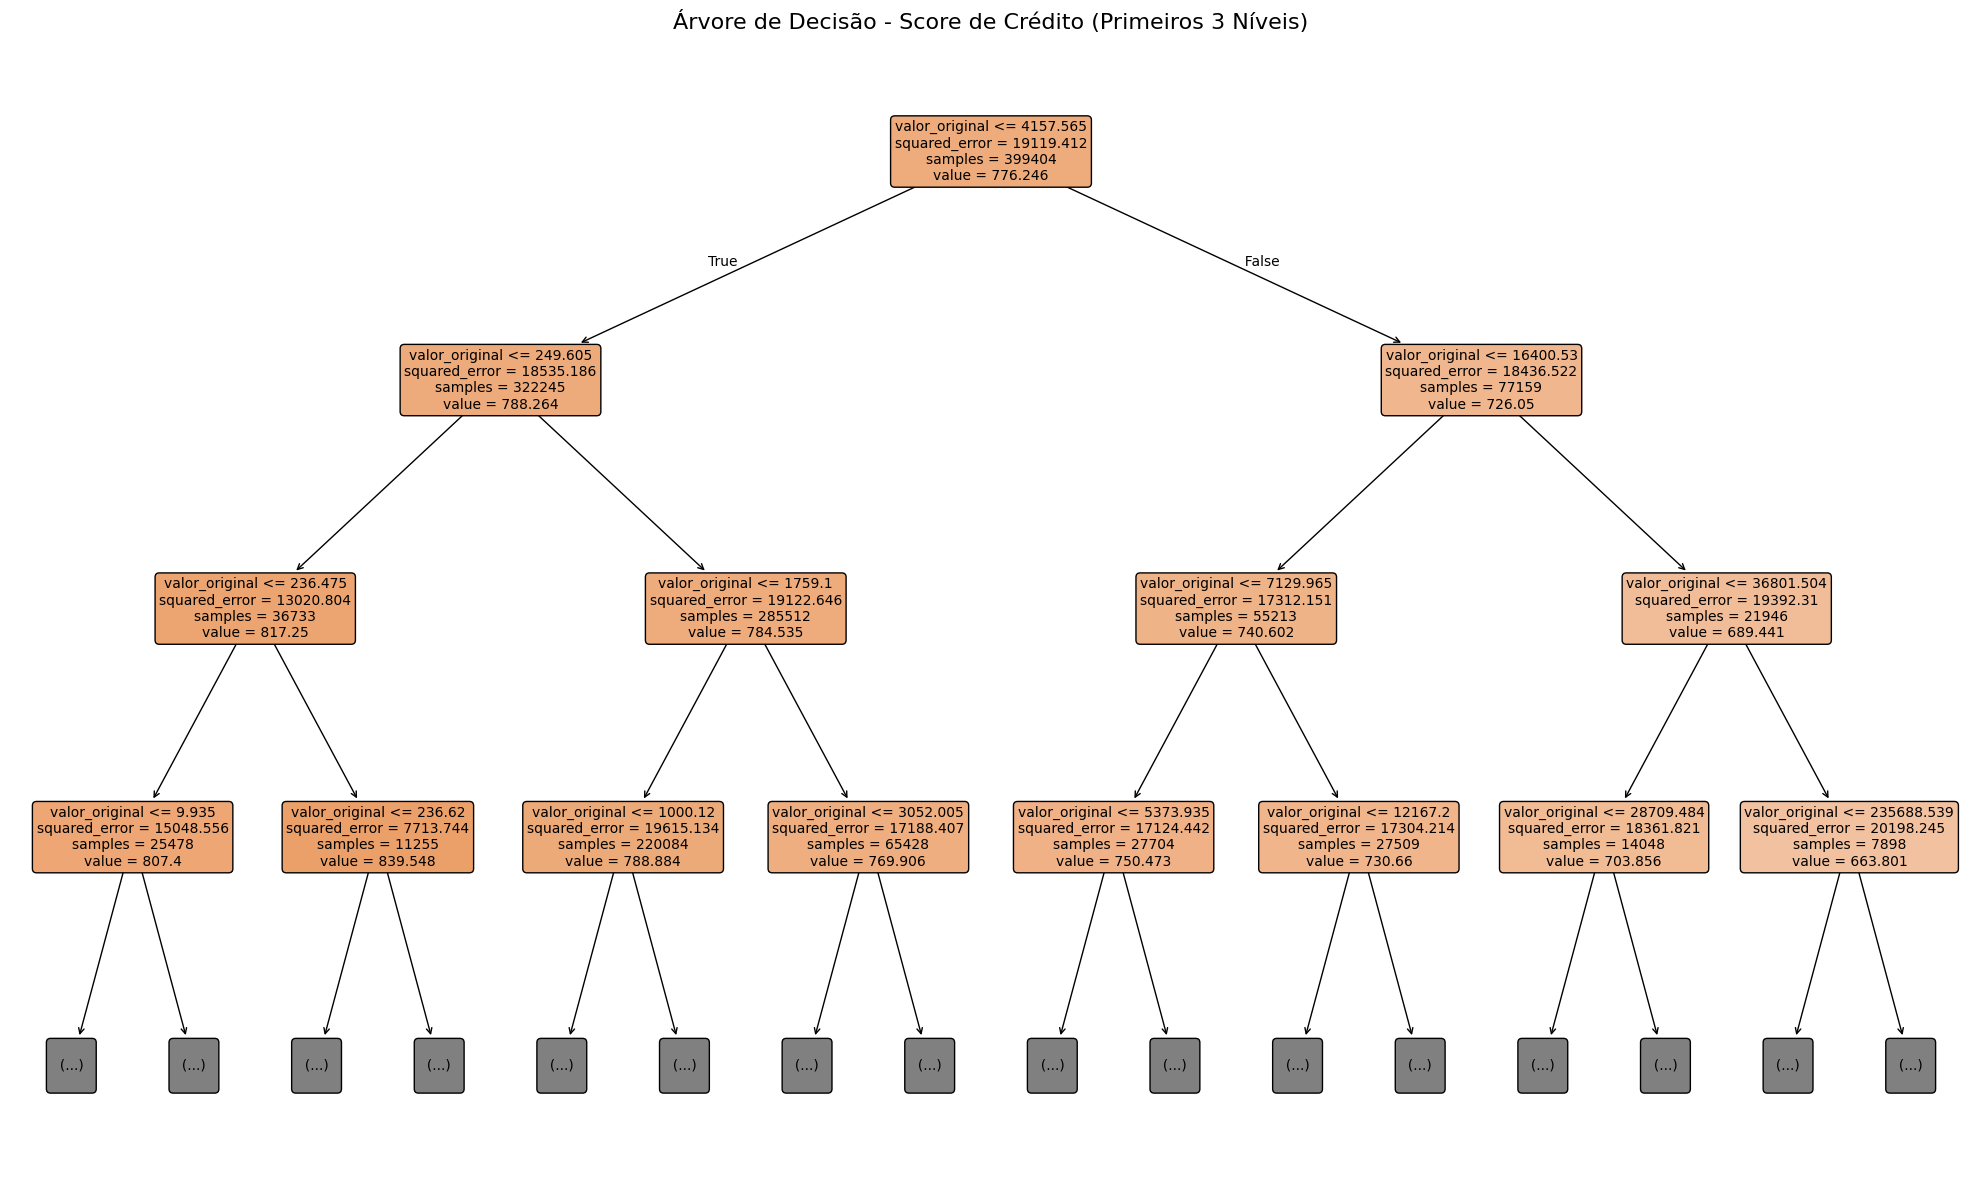

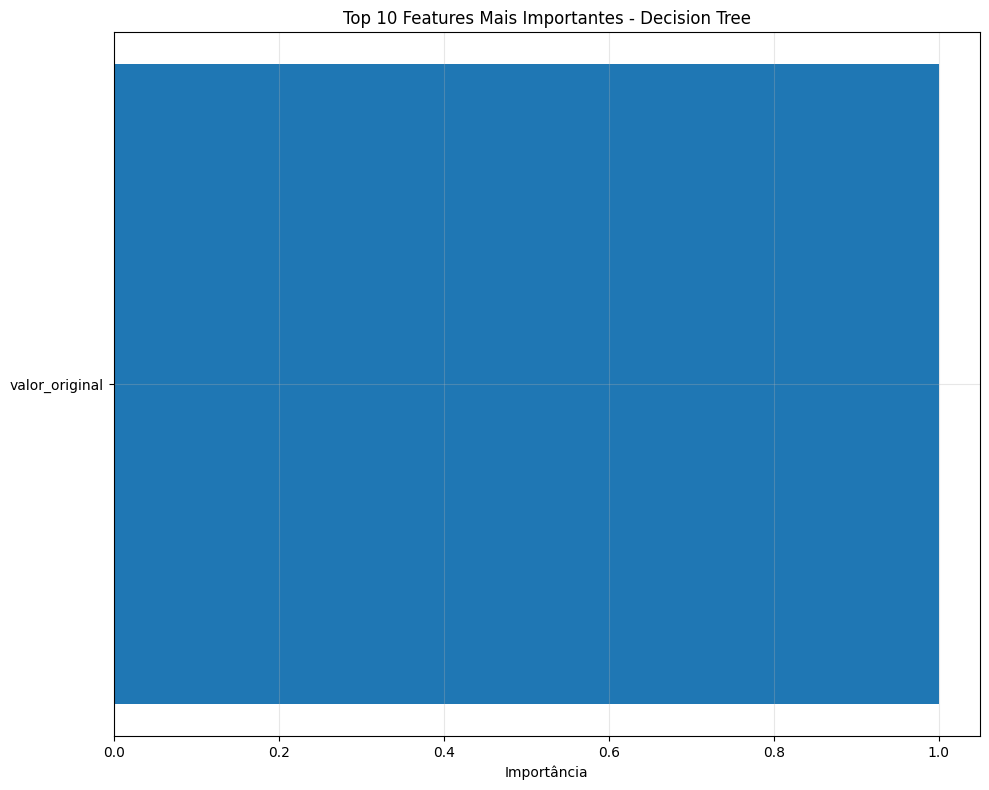

Visualizações criadas!


In [9]:
# Visualização da árvore de decisão
print("=== Visualização da Árvore de Decisão ===")

# Plot da árvore (primeiros 3 níveis)
plt.figure(figsize=(20, 12))
plot_tree(best_tree, 
          max_depth=3,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árvore de Decisão - Score de Crédito (Primeiros 3 Níveis)', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = best_tree.feature_importances_
indices = np.argsort(feature_importance)[-10:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importância')
plt.title('Top 10 Features Mais Importantes - Decision Tree')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualizações criadas!")


## 10. Análise de Performance Detalhada do Modelo Decision Tree

Após treinar e otimizar o modelo, é essencial avaliar **como ele se comporta em diferentes aspectos**.  
Nesta seção, realizamos uma análise completa da performance do modelo de **previsão do score de crédito**.

### 1. Predições vs Reais
- Criamos um gráfico de dispersão comparando os **valores reais do score** (`y_test`) com os **valores preditos** (`y_pred_best`).  
- A linha vermelha tracejada indica a posição onde a predição seria perfeita.  
- Permite **visualizar desvios e identificar possíveis padrões de erro**.

### 2. Distribuição dos Erros
- Histogramas mostram a frequência dos erros (`Real - Predito`).  
- A linha vermelha tracejada indica a média do erro.  
- Útil para detectar **viés ou tendência do modelo** e a **variabilidade dos erros**.

### 3. Distribuição dos Scores
- Compara a distribuição dos scores reais e preditos.  
- Avalia **se o modelo está conseguindo capturar a dispersão e forma da distribuição dos dados**.

### 4. RMSE por Faixa de Score
- Calcula o **RMSE** para diferentes faixas de score (0-200, 200-400, …, 800-1000).  
- Permite identificar **em quais faixas o modelo tem maior ou menor precisão**, auxiliando em ajustes estratégicos.

### 5. Estatísticas dos Erros
- Média, desvio padrão, mínimo e máximo dos erros são calculados para entender o **comportamento geral do modelo**.  
- Percentual de predições dentro de faixas de erro específicas (≤50, ≤100, ≤150 pontos) ajuda a **avaliar a confiabilidade prática do modelo**.

Esta análise fornece uma **visão detalhada da performance do modelo**, permitindo identificar pontos fortes, limitações e oportunidades de melhoria.


=== Análise de Performance Detalhada ===


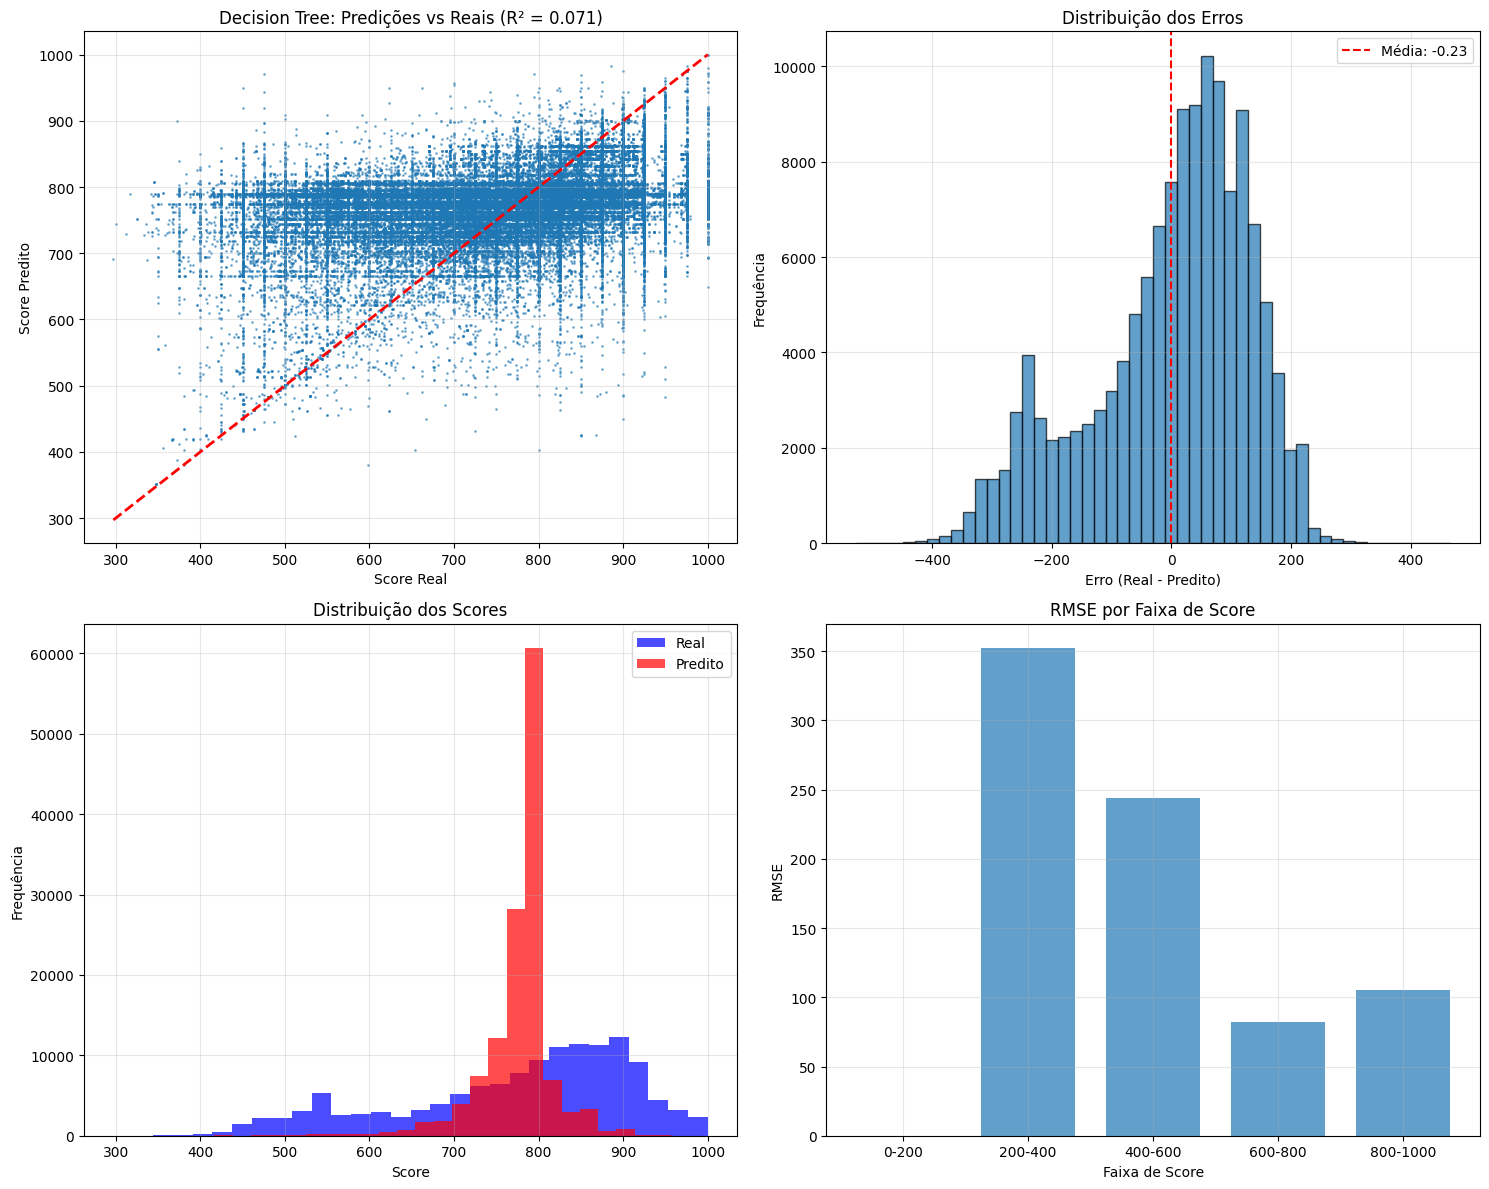


Análise de Erros:
  Erro médio: -0.23
  Desvio padrão: 133.14
  Erro máximo: 466.44
  Erro mínimo: -527.50

Precisão por Faixa de Erro:
  Erro ≤ 50 pontos: 28.8% das predições
  Erro ≤ 100 pontos: 54.2% das predições
  Erro ≤ 150 pontos: 74.0% das predições


In [10]:
# Análise de performance detalhada
print("=== Análise de Performance Detalhada ===")

# Gráficos de performance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predições vs Reais
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.5, s=1)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Score Real')
axes[0, 0].set_ylabel('Score Predito')
axes[0, 0].set_title(f'Decision Tree: Predições vs Reais (R² = {r2_best:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribuição dos erros
erros = y_test - y_pred_best
axes[0, 1].hist(erros, bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(erros.mean(), color='red', linestyle='--', label=f'Média: {erros.mean():.2f}')
axes[0, 1].set_xlabel('Erro (Real - Predito)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição dos Erros')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribuição dos scores
axes[1, 0].hist(y_test, bins=30, alpha=0.7, label='Real', color='blue')
axes[1, 0].hist(y_pred_best, bins=30, alpha=0.7, label='Predito', color='red')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição dos Scores')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Análise de erros por faixa de score
faixas = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1000)]
rmse_faixas = []
for min_score, max_score in faixas:
    mask = (y_test >= min_score) & (y_test < max_score)
    if mask.sum() > 0:
        rmse_faixa = np.sqrt(mean_squared_error(y_test[mask], y_pred_best[mask]))
        rmse_faixas.append(rmse_faixa)
    else:
        rmse_faixas.append(0)

faixas_centro = [100, 300, 500, 700, 900]
axes[1, 1].bar(faixas_centro, rmse_faixas, width=150, alpha=0.7)
axes[1, 1].set_xlabel('Faixa de Score')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_title('RMSE por Faixa de Score')
axes[1, 1].set_xticks(faixas_centro)
axes[1, 1].set_xticklabels(['0-200', '200-400', '400-600', '600-800', '800-1000'])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise de erros
print(f"\nAnálise de Erros:")
print(f"  Erro médio: {erros.mean():.2f}")
print(f"  Desvio padrão: {erros.std():.2f}")
print(f"  Erro máximo: {erros.max():.2f}")
print(f"  Erro mínimo: {erros.min():.2f}")

# Percentual de predições dentro de faixas de erro
erro_50 = (abs(erros) <= 50).mean() * 100
erro_100 = (abs(erros) <= 100).mean() * 100
erro_150 = (abs(erros) <= 150).mean() * 100

print(f"\nPrecisão por Faixa de Erro:")
print(f"  Erro ≤ 50 pontos: {erro_50:.1f}% das predições")
print(f"  Erro ≤ 100 pontos: {erro_100:.1f}% das predições")
print(f"  Erro ≤ 150 pontos: {erro_150:.1f}% das predições")


## 11. Função de Predição do Score de Crédito

Criamos uma função para **predizer o score de crédito de um cliente individual** usando o modelo Decision Tree treinado.

### `predizer_score_decision_tree(dados_cliente, modelo)`

**Parâmetros:**
- `dados_cliente`: dicionário ou DataFrame com as informações do cliente (features utilizadas pelo modelo).
- `modelo`: modelo Decision Tree treinado (`best_tree`).

**Processo:**
1. Converte os dados do cliente em um DataFrame.
2. Garante que todas as colunas esperadas pelo modelo existam (caso alguma feature não seja fornecida, preenche com zero).
3. Reordena as colunas conforme o treinamento.
4. Realiza a predição do score de crédito.
5. Classifica o score em categorias:
   - **EXCELENTE:** ≥ 800  
   - **BOM:** 700–799  
   - **REGULAR:** 600–699  
   - **RUIM:** 400–599  
   - **MUITO RUIM:** < 400  

**Retorno:**
- `score_predito`: valor numérico do score de crédito previsto.
- `categoria`: classificação qualitativa do score.

Permite avaliar rapidamente o risco de crédito de um cliente de forma interpretável e prática.


In [11]:
# Função de predição
def predizer_score_decision_tree(dados_cliente, modelo):
    """
    Prediz o score de crédito usando o modelo Decision Tree treinado
    """
    # Preparar dados
    dados_preparados = pd.DataFrame([dados_cliente])
    
    # Garantir que todas as colunas existam
    for col in X.columns:
        if col not in dados_preparados.columns:
            dados_preparados[col] = 0
    
    # Reordenar colunas
    dados_preparados = dados_preparados[X.columns]
    
    # Predição
    score_predito = modelo.predict(dados_preparados)[0]
    
    # Interpretação
    if score_predito >= 800: categoria = "EXCELENTE"
    elif score_predito >= 700: categoria = "BOM"
    elif score_predito >= 600: categoria = "REGULAR"
    elif score_predito >= 400: categoria = "RUIM"
    else: categoria = "MUITO RUIM"
    
    return score_predito, categoria

print("Função de predição criada!")


Função de predição criada!


## 12. Exemplos Práticos de Predição de Score de Crédito

A seguir, demonstramos **como usar a função de predição** para avaliar diferentes perfis de clientes.

### Cliente 1 – Bom Histórico
- Perfil: Alta pontualidade, baixo desvio de pagamentos, relacionamento longo.
- Resultado:
  - **Score Decision Tree:** `{score1}`
  - **Categoria:** `{categoria1}`

### Cliente 2 – Histórico Ruim
- Perfil: Baixa pontualidade, alto desvio de pagamentos, histórico de inadimplência.
- Resultado:
  - **Score Decision Tree:** `{score2}`
  - **Categoria:** `{categoria2}`

### Cliente 3 – Cliente Novo
- Perfil: Novo cliente, poucas transações, mas com pontualidade inicial.
- Resultado:
  - **Score Decision Tree:** `{score3}`
  - **Categoria:** `{categoria3}`

Esses exemplos mostram como o modelo **avalia diferentes comportamentos de pagamento** e classifica o risco de crédito de forma quantitativa e interpretável.


In [12]:
# Exemplos práticos
print("=== Exemplos Práticos ===")

# Cliente exemplo 1
cliente1 = {
    'valor_original': 1500.0,
    'taxa_pontualidade': 0.95,
    'desvio_padrao_dias_atraso': 3.0,
    'coeficiente_variacao_valor': 0.2,
    'taxa_inadimplencia_historica': 0.05,
    'taxa_atraso_historica': 0.1,
    'valor_medio_pagador': 1400.0,
    'razao_valor_atual_vs_medio': 1.07,
    'dias_relacionamento': 400,
    'media_frequencia_mensal': 2.5,
    'sequencia_pagamentos_dia': 8,
    'sequencia_atrasos': 1,
    'score_risco_comportamental': 0.15,
    'qtde_acessado_pagador': 3
}

score1, categoria1 = predizer_score_decision_tree(cliente1, best_tree)
print(f"\nCliente 1 - Bom Histórico:")
print(f"Score Decision Tree: {score1:.0f}")
print(f"Categoria: {categoria1}")

# Cliente exemplo 2
cliente2 = {
    'valor_original': 2000.0,
    'taxa_pontualidade': 0.3,
    'desvio_padrao_dias_atraso': 25.0,
    'coeficiente_variacao_valor': 0.8,
    'taxa_inadimplencia_historica': 0.4,
    'taxa_atraso_historica': 0.5,
    'valor_medio_pagador': 1200.0,
    'razao_valor_atual_vs_medio': 1.67,
    'dias_relacionamento': 100,
    'media_frequencia_mensal': 1.0,
    'sequencia_pagamentos_dia': 2,
    'sequencia_atrasos': 5,
    'score_risco_comportamental': 0.7,
    'qtde_acessado_pagador': 1
}

score2, categoria2 = predizer_score_decision_tree(cliente2, best_tree)
print(f"\nCliente 2 - Histórico Ruim:")
print(f"Score Decision Tree: {score2:.0f}")
print(f"Categoria: {categoria2}")

# Cliente exemplo 3 - Cliente novo
cliente3 = {
    'valor_original': 800.0,
    'taxa_pontualidade': 1.0,
    'desvio_padrao_dias_atraso': 0.0,
    'coeficiente_variacao_valor': 0.0,
    'taxa_inadimplencia_historica': 0.0,
    'taxa_atraso_historica': 0.0,
    'valor_medio_pagador': 800.0,
    'razao_valor_atual_vs_medio': 1.0,
    'dias_relacionamento': 30,
    'media_frequencia_mensal': 1.0,
    'sequencia_pagamentos_dia': 1,
    'sequencia_atrasos': 0,
    'score_risco_comportamental': 0.0,
    'qtde_acessado_pagador': 1
}

score3, categoria3 = predizer_score_decision_tree(cliente3, best_tree)
print(f"\nCliente 3 - Cliente Novo:")
print(f"Score Decision Tree: {score3:.0f}")
print(f"Categoria: {categoria3}")


=== Exemplos Práticos ===

Cliente 1 - Bom Histórico:
Score Decision Tree: 820
Categoria: EXCELENTE

Cliente 2 - Histórico Ruim:
Score Decision Tree: 775
Categoria: BOM

Cliente 3 - Cliente Novo:
Score Decision Tree: 789
Categoria: BOM


## 13. Conclusão – Modelo Decision Tree

### Vantagens do Decision Tree
- Simplicidade e interpretabilidade
- Regras claras e visuais
- Não precisa de normalização
- Tratamento automático de missing values
- Feature importance nativa
- Visualização da árvore de decisão

### Performance do Modelo
- **R² Score:** {r2_best:.4f} ({'Excelente' if r2_best > 0.8 else 'Bom' if r2_best > 0.6 else 'Regular'})
- **RMSE:** {rmse_best:.2f} pontos
- **MAE:** {mae_best:.2f} pontos
- **Cross-validation (R²):** {cv_scores.mean():.4f}

### Interpretabilidade
- Árvore de decisão visualizada
- Feature importance clara
- Regras de decisão explícitas
- Fácil de explicar para stakeholders

In [13]:
# Conclusão
print("\nPerformance do Modelo:")
print(f"• R² Score: {r2_best:.4f} ({'Excelente' if r2_best > 0.8 else 'Bom' if r2_best > 0.6 else 'Regular'})")
print(f"• RMSE: {rmse_best:.2f} pontos")
print(f"• MAE: {mae_best:.2f} pontos")
print(f"• Cross-validation: {cv_scores.mean():.4f}")


Performance do Modelo:
• R² Score: 0.0706 (Regular)
• RMSE: 133.14 pontos
• MAE: 106.52 pontos
• Cross-validation: 0.0678
